In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

In [36]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\Scalable E-commerce Data Pipeline & Analytics System\walmart_clean.csv")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51289 entries, 0 to 51288
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      51289 non-null  int64  
 1   category        51289 non-null  object 
 2   city            51289 non-null  object 
 3   country         51289 non-null  object 
 4   customer_id     51289 non-null  object 
 5   customer_name   51289 non-null  object 
 6   discount        51289 non-null  float64
 7   market          51289 non-null  object 
 8   order_date      51289 non-null  object 
 9   order_id        51289 non-null  object 
 10  order_priority  51289 non-null  object 
 11  product_id      51289 non-null  object 
 12  product_name    51289 non-null  object 
 13  profit          51289 non-null  float64
 14  quantity        51289 non-null  int64  
 15  region          51289 non-null  object 
 16  row_id          51289 non-null  int64  
 17  sales           51289 non-null 

In [13]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
df["profit_margin"] = df["profit"] / df["sales"]
df["delivery_days"] = (df["ship_date"] - df["order_date"]).dt.days
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.to_period("M")

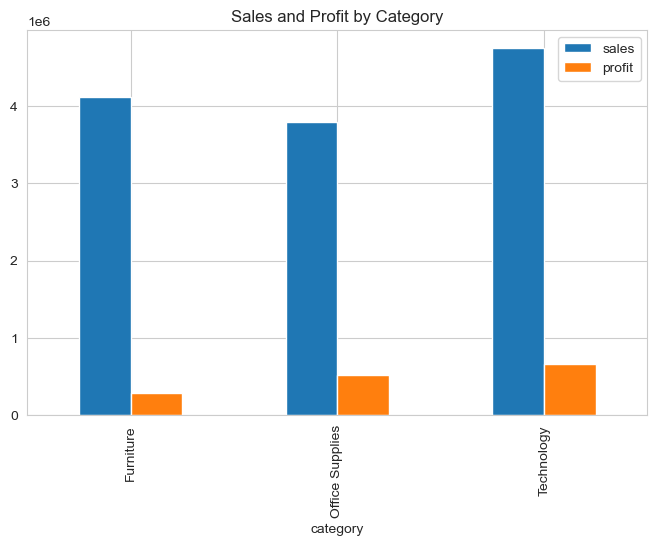

In [15]:
#Category Performance
category_performance = df.groupby("category")[["sales","profit"]].sum().reset_index()

category_performance.plot(x="category", kind="bar", figsize=(8,5))
plt.title("Sales and Profit by Category")
plt.show()

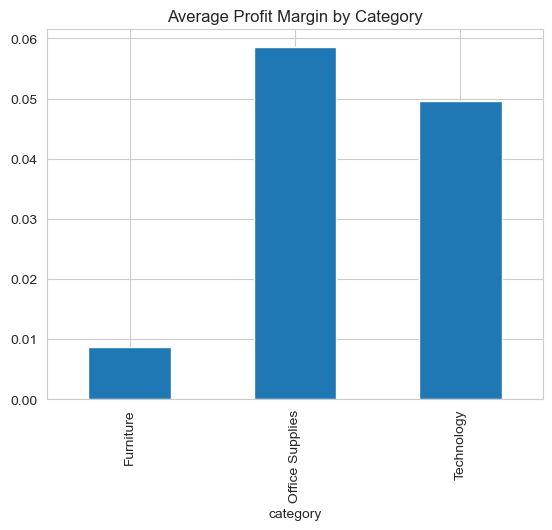

In [16]:
#Profit Margin
df.groupby("category")["profit_margin"].mean().plot(kind="bar")
plt.title("Average Profit Margin by Category")
plt.show()

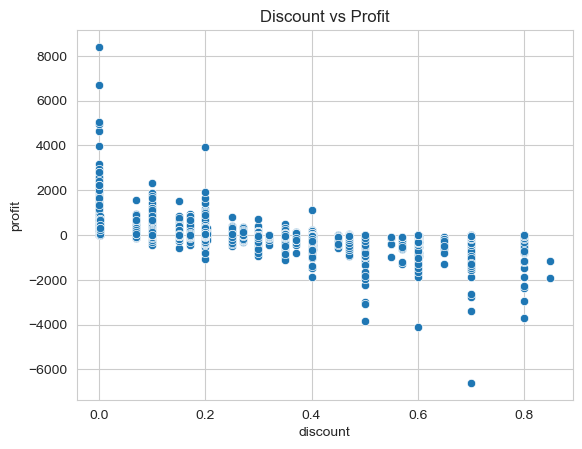

In [17]:
#Discount vs Profit
sns.scatterplot(x="discount", y="profit", data=df)
plt.title("Discount vs Profit")
plt.show()

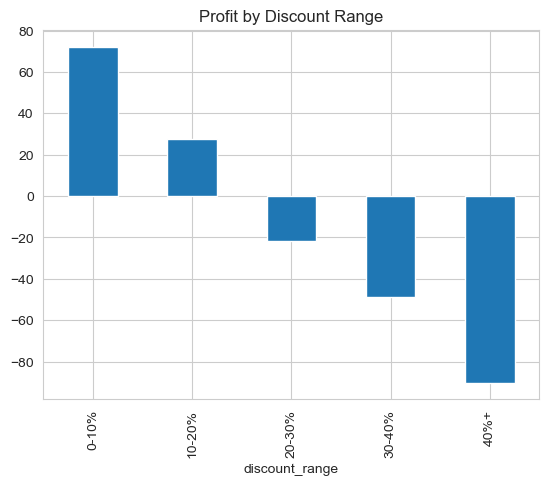

In [35]:
#Discount Buckets
bins = [0, 0.1, 0.2, 0.3, 0.4, 1]
labels = ["0-10%", "10-20%", "20-30%", "30-40%", "40%+"]

df["discount_range"] = pd.cut(df["discount"], bins=bins, labels=labels)

df.groupby("discount_range",observed=True)["profit"].mean().plot(kind="bar")
plt.title("Profit by Discount Range")
plt.show()

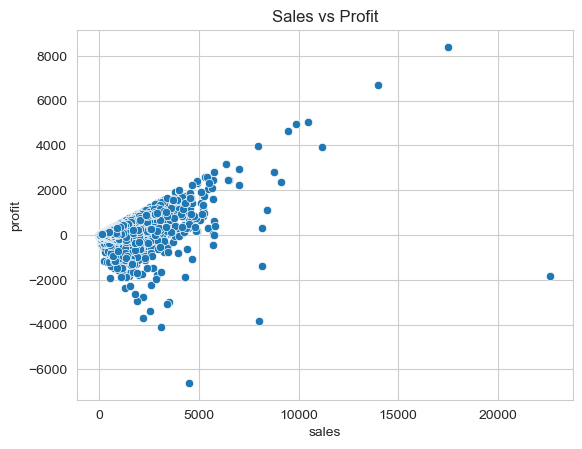

In [21]:
# Sales vs profit
sns.scatterplot(x="sales", y="profit", data=df)
plt.title("Sales vs Profit")
plt.show()

In [22]:
loss_pct = (df["profit"] < 0).mean() * 100
loss_pct

np.float64(24.45553627483476)

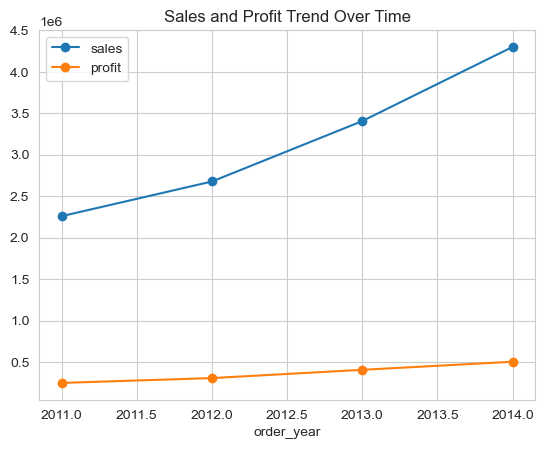

In [24]:
#Sales and Profit Trend Over Time
yearly = df.groupby("order_year")[["sales","profit"]].sum()

yearly.plot(kind="line", marker="o")
plt.title("Sales and Profit Trend Over Time")
plt.show()

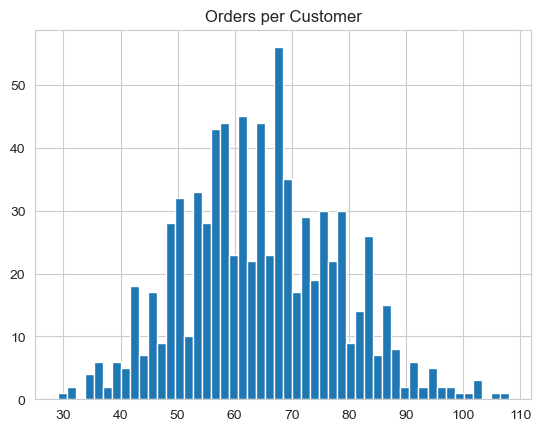

In [30]:
#Customer Analysis
orders_per_customer = df.groupby("customer_name")["order_id"].count()

orders_per_customer.hist(bins=50)
plt.title("Orders per Customer")
plt.show()

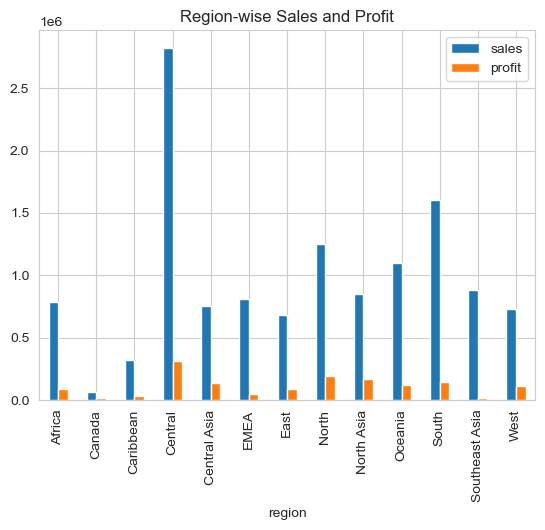

In [31]:
#Region Analysis
df.groupby("region")[["sales","profit"]].sum().plot(kind="bar")
plt.title("Region-wise Sales and Profit")
plt.show()

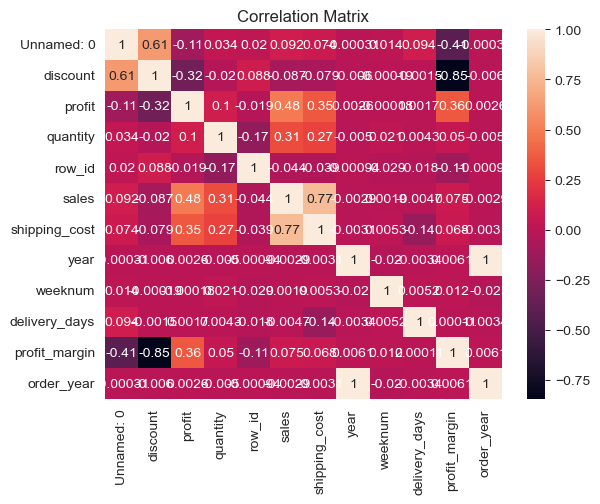

In [34]:
#Discount negatively impacts profit
numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()